In [1]:
import os, math, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_everything(SEED)

DEVICE = torch.device('cpu')

In [2]:
# ====== CẤU HÌNH ======
DATA_PATH   = '/kaggle/input/datasets/dhoogla/nfcsecicids2018v2/NF-CSE-CIC-IDS2018-V2.parquet'
LABEL_COL   = 'Label'
N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 1024
NUM_WORKERS = 4
EPOCHS      = 3
LR          = 1e-3
D_MODEL     = 64
N_HEADS     = 4
N_PERSIST   = 4
LMM_HIDDEN  = 128
OUTLIER_TH  = 3.0
PRE_BATCH   = 50000
SWA_WINDOW  = 16   
LMM_LAYERS  = 2    

## 1. Load parquet + xử lý cột constant & log transform

In [3]:
df = pd.read_parquet(DATA_PATH)
print('Raw shape:', df.shape)

std_series = df.std(numeric_only=True)
const_cols = std_series[std_series == 0].index.tolist()
print('Cột số constant:', const_cols)

if 'SRC_TO_DST_SECOND_BYTES' in df.columns:
    df['SRC_TO_DST_SECOND_BYTES_LOG'] = np.log1p(df['SRC_TO_DST_SECOND_BYTES'])
    df = df.drop(columns=['SRC_TO_DST_SECOND_BYTES'])

LABEL_MULTI = 'Attack' if 'Attack' in df.columns else 'Label'

drop_cols = [c for c in ['Label', 'Attack'] + const_cols if c in df.columns]
numerical_columns = [c for c in df.columns
                     if c not in drop_cols and np.issubdtype(df[c].dtype, np.number)]

X = df[numerical_columns].copy()
attack_raw = df[LABEL_MULTI].astype(str).fillna('Benign').values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(attack_raw).astype(np.int64)
CLASS_NAMES = list(label_encoder.classes_)
for i, name in enumerate(CLASS_NAMES):
    cnt = int((y == i).sum())
    print(f'  {i:2d} - {name}: {cnt:,}')


Raw shape: (17129715, 43)
Cột số constant: ['FTP_COMMAND_RET_CODE']
   0 - Benign: 15,101,685
   1 - Bot: 28,033
   2 - Brute Force -Web: 2,143
   3 - Brute Force -XSS: 927
   4 - DDOS attack-HOIC: 1,066,881
   5 - DDOS attack-LOIC-UDP: 2,112
   6 - DDoS attacks-LOIC-HTTP: 207,078
   7 - DoS attacks-GoldenEye: 27,723
   8 - DoS attacks-Hulk: 432,648
   9 - DoS attacks-SlowHTTPTest: 14,116
  10 - DoS attacks-Slowloris: 9,512
  11 - FTP-BruteForce: 25,933
  12 - Infilteration: 115,513
  13 - SQL Injection: 432
  14 - SSH-Bruteforce: 94,979


## 2. Split train / val / test (stratified)

In [4]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
print(f'Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}')
del X, X_tmp, y_tmp, df; gc.collect()

Train: (11990800, 40) | Val: (1712971, 40) | Test: (3425944, 40)


0

## 3. Robust preprocessing theo batch (NaN / Inf / Outlier)

In [5]:
def robust_preprocess_large_data(X_train, X_val, X_test,
                                  batch_size=50000, outlier_threshold=3.0):
    if hasattr(X_train, 'values'): X_train = X_train.values
    if hasattr(X_val, 'values'):   X_val   = X_val.values
    if hasattr(X_test, 'values'):  X_test  = X_test.values
    X_train = X_train.astype(np.float32)
    X_val   = X_val.astype(np.float32)
    X_test  = X_test.astype(np.float32)

    sample_size = min(100000, len(X_train))
    idx = np.random.choice(len(X_train), sample_size, replace=False)
    X_sample = X_train[idx].copy()
    medians = np.nanmedian(X_sample, axis=0)
    stds    = np.nanstd(X_sample, axis=0)
    stds[stds == 0] = 1.0

    def process(batch):
        batch = batch.copy()
        batch[np.isinf(batch)] = np.nan
        for col in range(batch.shape[1]):
            cd = batch[:, col]; med = medians[col]; sd = stds[col]
            z = np.abs((cd - med) / sd)
            mask = z > outlier_threshold
            if mask.any(): batch[mask, col] = med
            nan_mask = np.isnan(batch[:, col])
            if nan_mask.any(): batch[nan_mask, col] = med
        return np.clip(batch, -1e6, 1e6)

    def by_batch(arr, name):
        n = len(arr); nb = int(np.ceil(n / batch_size)); out = []
        for i in range(nb):
            s, e = i*batch_size, min((i+1)*batch_size, n)
            out.append(process(arr[s:e]))
            if (i+1) % 20 == 0 or (i+1) == nb:
                print(f'  {name}: {e:,}/{n:,}')
        return np.vstack(out)

    Xtr = by_batch(X_train, 'train')
    Xva = by_batch(X_val,   'val  ')
    Xte = by_batch(X_test,  'test ')
    return Xtr, Xva, Xte

X_tr_p, X_val_p, X_te_p = robust_preprocess_large_data(
    X_tr, X_val, X_te, batch_size=PRE_BATCH, outlier_threshold=OUTLIER_TH)
del X_tr, X_val, X_te; gc.collect()

  train: 1,000,000/11,990,800
  train: 2,000,000/11,990,800
  train: 3,000,000/11,990,800
  train: 4,000,000/11,990,800
  train: 5,000,000/11,990,800
  train: 6,000,000/11,990,800
  train: 7,000,000/11,990,800
  train: 8,000,000/11,990,800
  train: 9,000,000/11,990,800
  train: 10,000,000/11,990,800
  train: 11,000,000/11,990,800
  train: 11,990,800/11,990,800
  val  : 1,000,000/1,712,971
  val  : 1,712,971/1,712,971
  test : 1,000,000/3,425,944
  test : 2,000,000/3,425,944
  test : 3,000,000/3,425,944
  test : 3,425,944/3,425,944


0

## 4. PCA giảm chiều (40 → 20)

In [6]:
pca = PCA(n_components=N_PCA, random_state=SEED)
X_tr_pca  = pca.fit_transform(X_tr_p)
X_val_pca = pca.transform(X_val_p)
X_te_pca  = pca.transform(X_te_p)

evr = pca.explained_variance_ratio_
del X_tr_p, X_val_p, X_te_p; gc.collect()

0

## 5. StandardScaler + Tokenize bằng KBinsDiscretizer

In [7]:
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_pca)
X_val_sc = scaler.transform(X_val_pca)
X_te_sc  = scaler.transform(X_te_pca)

kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr_sc).astype(np.int64)
tok_val = kbd.transform(X_val_sc).astype(np.int64)
tok_te  = kbd.transform(X_te_sc).astype(np.int64)

ordered_vocab = [int(max(tok_tr[:, i].max(), tok_val[:, i].max(), tok_te[:, i].max())) + 2
                 for i in range(tok_tr.shape[1])]
SEQ_LEN_FINAL = tok_tr.shape[1]
N_CLASSES = len(np.unique(y_tr))

## 6. Dataset & DataLoader

In [8]:
class TokenDS(Dataset):
    def __init__(self, X_tok, y):
        self.X = torch.from_numpy(X_tok).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = TokenDS(tok_tr,  y_tr)
val_ds   = TokenDS(tok_val, y_val)
test_ds  = TokenDS(tok_te,  y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

## 7. Kiến trúc Titan MAG

In [9]:
# ==================== Rotary Positional Encoding (RoPE) ====================
def build_rope_cache(seq_len, head_dim, device, base=10000.0):
    assert head_dim % 2 == 0, "head_dim phải chia hết cho 2 để dùng RoPE"
    half = head_dim // 2
    freqs = 1.0 / (base ** (torch.arange(0, half, device=device).float() / half))
    t = torch.arange(seq_len, device=device).float()
    angles = torch.outer(t, freqs)
    cos = angles.cos().repeat_interleave(2, dim=-1)
    sin = angles.sin().repeat_interleave(2, dim=-1)
    return cos, sin

def apply_rope(x, cos, sin):
    x1 = x[..., 0::2]; x2 = x[..., 1::2]
    x_rot = torch.stack((-x2, x1), dim=-1).flatten(-2)
    return x * cos + x_rot * sin


class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d_model):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d_model) for v in vocab_sizes])
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        B, L = x.shape
        out = torch.stack([self.embs[i](x[:, i]) for i in range(L)], dim=1)
        return self.norm(out)


class DimReduceBlock(nn.Module):
    def __init__(self, d_model, latent_dim=None):
        super().__init__()
        if latent_dim is None:
            latent_dim = d_model // 2
        self.encoder = nn.Sequential(nn.Linear(d_model, latent_dim), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(latent_dim, d_model),  nn.ReLU())
        self.norm    = nn.LayerNorm(d_model)
    def forward(self, x):
        return self.norm(self.decoder(self.encoder(x)))


class HiddenMLP(nn.Module):
    def __init__(self, d_model, expansion=2, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_model * expansion),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * expansion, d_model),
            nn.ReLU(),
        )
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        return self.norm(x + self.net(x))


class NeuralLongTermMemory(nn.Module):
    def __init__(self, d_model, hidden=128, n_layers=2):
        super().__init__()
        layers = []
        in_dim = d_model
        for _ in range(n_layers - 1):
            layers += [nn.Linear(in_dim, hidden), nn.ReLU()]
            in_dim  = hidden
        layers.append(nn.Linear(in_dim, d_model))
        self.M = nn.Sequential(*layers)   

        self.key   = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.query = nn.Linear(d_model, d_model)
        self.alpha_net = nn.Linear(d_model, 1)   
        self.eta_net   = nn.Linear(d_model, 1)  
        self.theta_net = nn.Linear(d_model, 1)   
        self.out_norm  = nn.LayerNorm(d_model)

    def forward(self, h):
        B, L, D = h.shape
        k = self.key(h); v = self.value(h); q = self.query(h)
        alpha = torch.sigmoid(self.alpha_net(h))
        eta   = torch.sigmoid(self.eta_net(h))
        theta = torch.sigmoid(self.theta_net(h)) * 0.1
        Mt = torch.zeros(B, D, device=h.device)
        St = torch.zeros(B, D, device=h.device)
        outs = []
        for t in range(L):
            kt, vt, qt = k[:, t], v[:, t], q[:, t]
            v_hat = self.M(kt) + Mt           
            grad  = 2.0 * (v_hat - vt)        
            St = eta[:, t] * St - theta[:, t] * grad   
            Mt = (1 - alpha[:, t]) * Mt + St            
            outs.append(self.M(qt) + Mt)      
        return self.out_norm(torch.stack(outs, dim=1))


class SlidingWindowAttention(nn.Module):
    def __init__(self, d_model, n_heads, window=16):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        assert self.head_dim % 2 == 0, "head_dim phải chẵn để dùng RoPE"
        self.qkv  = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.window = window
    def forward(self, x):
        B, L, D = x.shape
        qkv = self.qkv(x).reshape(B, L, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        cos, sin = build_rope_cache(L, self.head_dim, x.device)
        cos = cos.unsqueeze(0).unsqueeze(0); sin = sin.unsqueeze(0).unsqueeze(0)
        q = apply_rope(q, cos, sin); k = apply_rope(k, cos, sin)
        idx  = torch.arange(L, device=x.device)
        diff = idx.unsqueeze(0) - idx.unsqueeze(1)
        block = (diff > 0) | (diff < -(self.window - 1))   
        attn_mask = torch.where(block, torch.tensor(float('-inf'), device=x.device), torch.tensor(0.0, device=x.device))
        y = torch.nn.functional.scaled_dot_product_attention(q, k, v, attn_mask=attn_mask, is_causal=False)
        y = y.transpose(1, 2).contiguous().reshape(B, L, D)
        return self.norm(x + self.proj(y))


class TitanMAG(nn.Module):
    def __init__(self, vocab_sizes, n_classes, d_model=64, n_heads=4,
                 n_persist=4, lmm_hidden=128, swa_window=16, lmm_layers=2):
        super().__init__()
        self.embed      = FeatureEmbedding(vocab_sizes, d_model)
        self.persistent = nn.Parameter(torch.randn(1, n_persist, d_model) * 0.02)
        self.dim_reduce = DimReduceBlock(d_model)

        self.hidden_mlp = HiddenMLP(d_model)
 
        self.stm        = SlidingWindowAttention(d_model, n_heads, window=swa_window)
        self.lmm        = NeuralLongTermMemory(d_model, hidden=lmm_hidden, n_layers=lmm_layers)

        self.combine    = nn.Linear(d_model * 2, d_model)

        self.gate_proj  = nn.Linear(d_model, d_model)
        self.gate_norm  = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(d_model, n_classes)
        )
        self.n_persist = n_persist

    def forward(self, x):
        B = x.size(0)

        h = self.embed(x)                                

        h = self.dim_reduce(h)                       

        h = self.hidden_mlp(h)                              

        persist  = self.persistent.expand(B, -1, -1)         
        x_tilde  = torch.cat([persist, h], dim=1)            

        y_swa = self.stm(x_tilde)                            
        y_lmm = self.lmm(x_tilde)                            

        # Gop + gate
        attn_out = self.combine(torch.cat([y_swa, y_lmm], dim=-1))   
        out = self.gate_norm(
            attn_out * torch.sigmoid(self.gate_proj(x_tilde))        
        )

        out    = out[:, self.n_persist:]                      
        pooled = out.mean(dim=1)                              
        return self.head(pooled)


model = TitanMAG(ordered_vocab, N_CLASSES, D_MODEL, N_HEADS,
                 N_PERSIST, LMM_HIDDEN, SWA_WINDOW, LMM_LAYERS).to(DEVICE)

In [10]:
from sklearn.manifold import TSNE
import numpy as np

N_TSNE = 3000
np.random.seed(SEED)
idx_before = np.random.choice(len(tok_tr), N_TSNE, replace=False)
X_before   = tok_tr[idx_before].astype(np.float32)
y_before   = y_tr[idx_before]

tsne_before = TSNE(
    n_components=2, perplexity=40, random_state=SEED,
    init="pca", learning_rate="auto"
).fit_transform(X_before)


## 8. Train

In [11]:
def evaluate(model, loader):
    model.eval(); all_p, all_t = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            all_p.append(logits.argmax(-1).cpu().numpy())
            all_t.append(yb.numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t)
    return {'acc':  accuracy_score(t, p),
            'f1':   f1_score(t, p, average='weighted', zero_division=0),
            'prec': precision_score(t, p, average='weighted', zero_division=0),
            'rec':  recall_score(t, p, average='weighted', zero_division=0),
            'pred': p, 'true': t}

class FocalLoss(nn.Module):
  
    def __init__(self, gamma: float = 2.0, alpha=None, reduction: str = "mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha         
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_prob = F.log_softmax(logits, dim=-1)          
        prob     = log_prob.exp()                          

        log_pt = log_prob.gather(1, targets.unsqueeze(1)).squeeze(1)   
        pt     = prob.gather(1, targets.unsqueeze(1)).squeeze(1)        

        focal_weight = (1.0 - pt) ** self.gamma

        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]             # (B,)
            focal_weight = alpha_t * focal_weight

        loss = -focal_weight * log_pt   # (B,)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss



criterion = FocalLoss(gamma=2.0, alpha=None)  
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


history = []
for epoch in range(1, EPOCHS + 1):
    model.train(); losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()
    m = evaluate(model, val_loader)
    history.append({'epoch': epoch, 'loss': float(np.mean(losses)),
                    **{k: m[k] for k in ['acc','f1','prec','rec']}})
    print(f'[Epoch {epoch}/{EPOCHS}] loss={np.mean(losses):.4f} | '
          f'acc={m["acc"]:.4f} | f1_w={m["f1"]:.4f} | '
          f'prec_w={m["prec"]:.4f} | rec_w={m["rec"]:.4f}')


[Epoch 1/3] loss=0.0141 | acc=0.9942 | f1_w=0.9926 | prec_w=0.9940 | rec_w=0.9942
[Epoch 2/3] loss=0.0100 | acc=0.9943 | f1_w=0.9927 | prec_w=0.9942 | rec_w=0.9943
[Epoch 3/3] loss=0.0095 | acc=0.9946 | f1_w=0.9932 | prec_w=0.9944 | rec_w=0.9946


## 9. Đánh giá trên tập TEST + Confusion Matrix


===== FINAL TEST METRICS =====
Accuracy        : 0.9946
F1 (weighted)   : 0.9932
F1 (macro)      : 0.7843
Precision (w)   : 0.9943
Recall (w)      : 0.9946

----- Classification Report -----
                          precision    recall  f1-score   support

                  Benign     0.9944    0.9998    0.9971   3020338
                     Bot     0.9998    0.9993    0.9996      5607
        Brute Force -Web     0.8169    0.1352    0.2320       429
        Brute Force -XSS     1.0000    0.1243    0.2212       185
        DDOS attack-HOIC     0.9972    1.0000    0.9986    213376
    DDOS attack-LOIC-UDP     0.9833    0.9763    0.9798       422
  DDoS attacks-LOIC-HTTP     0.9993    0.9999    0.9996     41415
   DoS attacks-GoldenEye     0.9814    0.9493    0.9651      5545
        DoS attacks-Hulk     0.9966    0.9985    0.9976     86529
DoS attacks-SlowHTTPTest     0.9996    1.0000    0.9998      2823
   DoS attacks-Slowloris     0.9409    0.9543    0.9476      1903
          FTP-B

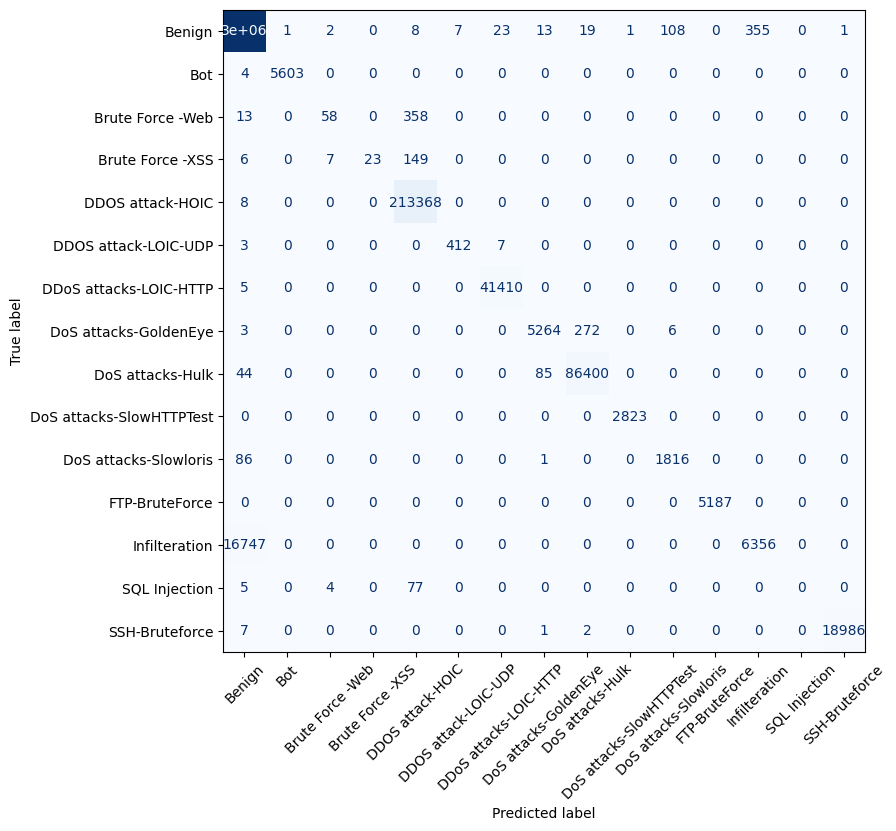

In [12]:
m = evaluate(model, test_loader)
print('\n===== FINAL TEST METRICS =====')
print(f'Accuracy        : {m["acc"]:.4f}')
print(f'F1 (weighted)   : {m["f1"]:.4f}')
print(f'F1 (macro)      : {f1_score(m["true"], m["pred"], average="macro", zero_division=0):.4f}')
print(f'Precision (w)   : {m["prec"]:.4f}')
print(f'Recall (w)      : {m["rec"]:.4f}')

print('\n----- Classification Report -----')
print(classification_report(m['true'], m['pred'],
                            target_names=CLASS_NAMES, zero_division=0, digits=4))

labels_idx = list(range(len(CLASS_NAMES)))
cm = confusion_matrix(m['true'], m['pred'], labels=labels_idx)
size = max(6, len(CLASS_NAMES) * 0.6)
fig, ax = plt.subplots(figsize=(size, size))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
plt.tight_layout(); plt.show()


T-SNE After RoPE done.


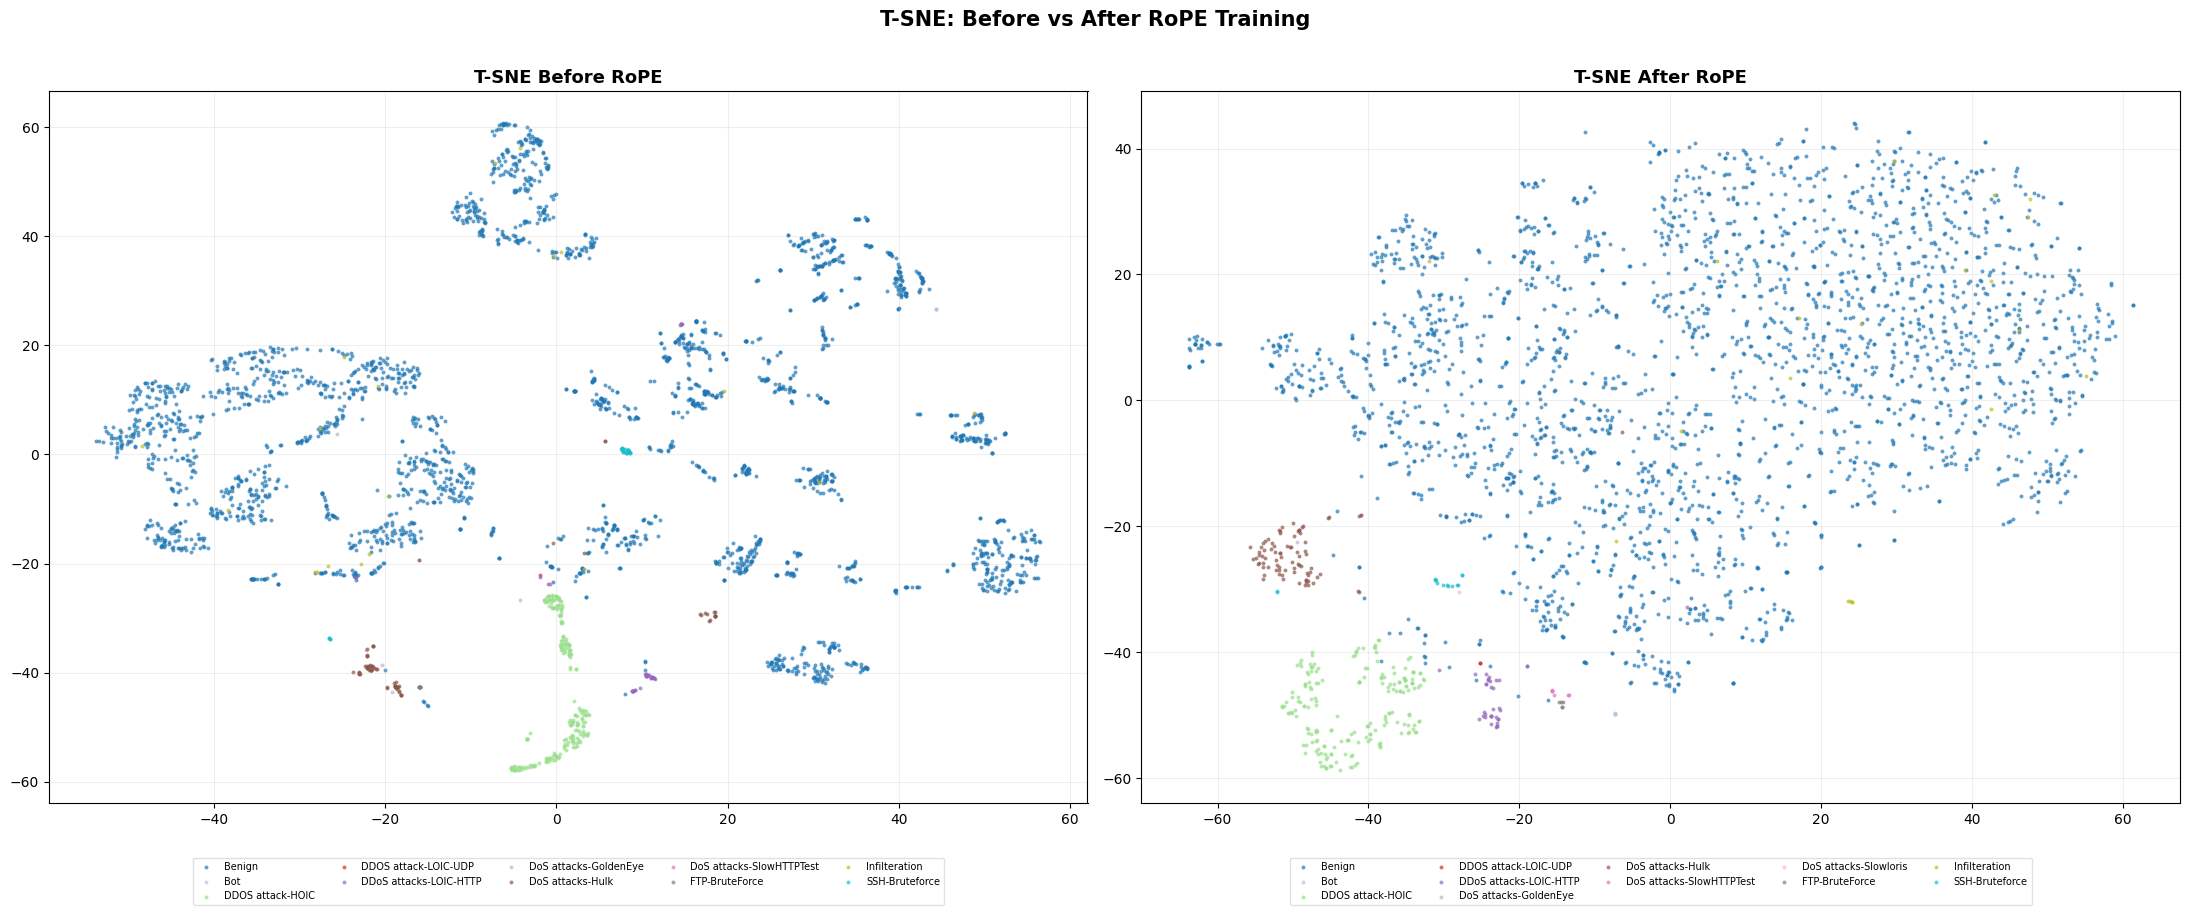

Saved: tsne_before_after_rope.png


In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch

def extract_rope_embeddings(model, loader, n_samples=3000, device=DEVICE):
    model.eval()
    all_embs, all_labels, collected = [], [], 0
    with torch.no_grad():
        for xb, yb in loader:
            if collected >= n_samples:
                break
            xb = xb.to(device)
            h = model.embed(xb)       # (B, L, D) feature embeddings
            h = model.dim_reduce(h)   # (B, L, D) after DimReduce
            h = model.hidden_mlp(h)   # (B, L, D) after HiddenMLP
            pooled = h.mean(dim=1)    # (B, D)
            all_embs.append(pooled.cpu().numpy())
            all_labels.append(yb.numpy())
            collected += xb.size(0)
    return (np.concatenate(all_embs,   axis=0)[:n_samples],
            np.concatenate(all_labels, axis=0)[:n_samples])

N_TSNE = 3000
X_after, y_after = extract_rope_embeddings(model, test_loader, n_samples=N_TSNE)

tsne_after = TSNE(
    n_components=2, perplexity=40, random_state=SEED,
    init="pca", learning_rate="auto"
).fit_transform(X_after)
print("T-SNE After RoPE done.")

cmap   = plt.get_cmap("tab20")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

for i, name in enumerate(CLASS_NAMES):
    color = [cmap(i / len(CLASS_NAMES))]
    
    m1 = y_before == i
    if m1.sum() > 0:
        ax1.scatter(tsne_before[m1, 0], tsne_before[m1, 1],
                    c=color, label=name, s=8, alpha=0.7, linewidths=0)
    
    m2 = y_after == i
    if m2.sum() > 0:
        ax2.scatter(tsne_after[m2, 0], tsne_after[m2, 1],
                    c=color, label=name, s=8, alpha=0.7, linewidths=0)

ax1.set_title("T-SNE Before RoPE", fontsize=13, fontweight="bold")
ax1.grid(alpha=0.2)
ax1.legend(bbox_to_anchor=(0.5, -0.07), loc="upper center",
           ncol=5, fontsize=7, framealpha=0.6)

ax2.set_title("T-SNE After RoPE", fontsize=13, fontweight="bold")
ax2.grid(alpha=0.2)
ax2.legend(bbox_to_anchor=(0.5, -0.07), loc="upper center",
           ncol=5, fontsize=7, framealpha=0.6)

fig.suptitle("T-SNE: Before vs After RoPE Training", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tsne_before_after_rope.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tsne_before_after_rope.png")
